# MgCl₂(aq) 12-6-4：结构预览 / 热力学 / RDF·CN / 水合壳 XYZ

| 文件 | 用途 |
|------|------|
| `log.lammps` | 温度 / 压力 / 密度 |
| `result_atoms.eq.data` + `result_atoms.lammpstrj` | 生产段轨迹（unwrap `xsu ysu zsu`） |
| `_extract_hydrated_ions.py` | 任意离子 + 壳层水 → `hydrated_ion/*.xyz`（通用截断 / selection） |

体系：**2 Mg²⁺ + 4 Cl⁻ + 800 SPC/E**（type 1=Mg，2=Cl，3=Hw，4=Ow）。  
模拟：NVT 100 ps + NPT 400 ps → NPT 生产 1 ns、500 帧（见 `in.lmp`）。  
分析：同时给出 **Mg–Ow** 与 **Cl–Ow** 的 $g(r)$ / CN，并分别导出水合壳。


In [1]:
%reload_ext autoreload
%autoreload 2
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "figure.facecolor": "white",
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "font.size": 10,
})
from MDAnalysis import transformations as trans
from MDAnalysis.analysis.rdf import InterRDF
import nglview as nv
import warnings
warnings.filterwarnings("ignore")

from _helper_functions import (
    load_lammps_universe,
    read_result_thermo,
    move_origin_to_corner,
    save_nglview_frame,
)


# ---- 本例参数 ----
N_MG, N_CL, N_WATER = 2, 4, 800
RESNAMES = ["Mg"] * N_MG + ["Cl"] * N_CL + ["H2O"] * N_WATER

def _pick_topo():
    for p in ("./result_atoms.eq.data", "./result_atoms.data", "./data.lmp"):
        if Path(p).exists():
            return p
    raise FileNotFoundError("need result_atoms.eq.data / result_atoms.data / data.lmp")

TOPO = _pick_topo()
TRAJ = "./result_atoms.lammpstrj"
DT_FS = 2000.0          # dump_every * timestep [fs] → 2 ps
T_TARGET = 298.0
P_TARGET = 1.0





print("TOPO =", TOPO)
print("TRAJ =", TRAJ, "exists =", Path(TRAJ).exists())


TOPO = ./result_atoms.eq.data
TRAJ = ./result_atoms.lammpstrj exists = True


## 1. 预览结构

读生产轨迹；显示时按 **residue** wrap。残基名与 LAMMPS mol 升序一致：2×Mg、4×Cl、800×H2O。

nglview 晶胞框**不会**随 NPT 每帧更新，只作快速验结构。


In [2]:
u_view = load_lammps_universe(TOPO, TRAJ, dt_fs=DT_FS, resnames=RESNAMES)
u_view.trajectory.add_transformations(
    move_origin_to_corner,
    trans.wrap(u_view.atoms, compound="residues"),
)
print(f"frames = {u_view.trajectory.n_frames}, atoms = {u_view.atoms.n_atoms}")

view = nv.show_mdanalysis(u_view)
view.clear_representations()
view.add_representation("spacefill", selection="Mg", radius=0.9)
view.add_representation("spacefill", selection="Cl", radius=1.0)
view.add_representation("licorice", selection="H2O", radius=0.15)
view.add_unitcell()

box dimensions: [28.930716 28.930716 28.930716 90.       90.       90.      ]
frame num: 287
frames = 287, atoms = 2406


In [3]:
view

NGLWidget(max_frame=286)

In [4]:
# 导出某一帧 PNG（默认最后一帧）
# save_nglview_frame(view, "result_nglview.png")

## 2. 热力学：温度、压力、密度

读全部 thermo 块（预松弛 / NVT / NPT 平衡 / 生产）。列名小写。生产段取最后一块。


thermo blocks / rows: 4 288
columns: ['segment', 'step', 'temp', 'e_pair', 'e_mol', 'toteng', 'press', 'time', 'lx', 'ly', 'lz', 'density', 'volume', 'poteng', 'kineng']


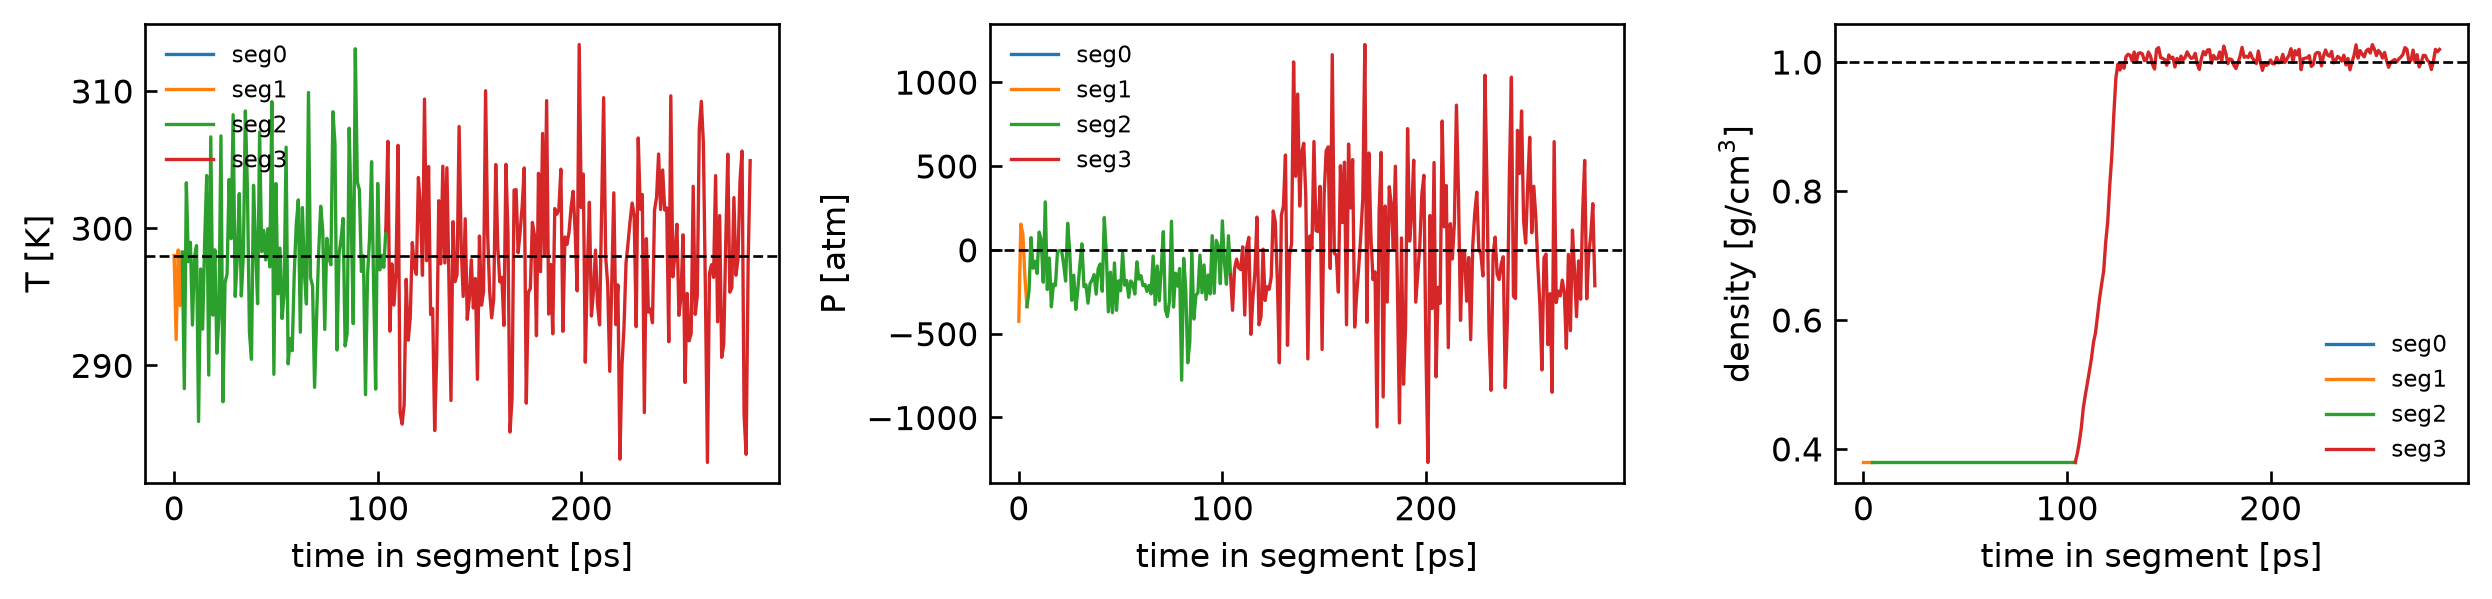

production mean: T=297.69 K, P=11.76 atm, density=0.9604 g/cm^3, L=(29.556, 29.556, 29.556) Å


In [5]:
thermo_all = read_result_thermo("log.lammps", segment=None)
print("thermo blocks / rows:", thermo_all["segment"].nunique(), len(thermo_all))
print("columns:", list(thermo_all.columns))

fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.6))
for seg, g in thermo_all.groupby("segment"):
    t_ps = g["time"].to_numpy() / 1000.0  # fs → ps（段内）
    label = f"seg{seg}"
    axes[0].plot(t_ps, g["temp"], lw=1.0, label=label)
    axes[1].plot(t_ps, g["press"], lw=1.0, label=label)
    axes[2].plot(t_ps, g["density"], lw=1.0, label=label)

axes[0].set_ylabel("T [K]")
axes[0].axhline(T_TARGET, color="k", ls="--", lw=0.8)
axes[1].set_ylabel("P [atm]")
axes[1].axhline(P_TARGET, color="k", ls="--", lw=0.8)
axes[2].set_ylabel(r"density [g/cm$^3$]")
axes[2].axhline(1.0, color="k", ls="--", lw=0.8)
for ax in axes:
    ax.set_xlabel("time in segment [ps]")
    ax.tick_params(direction="in")
    ax.legend(fontsize=7, frameon=False)

fig.tight_layout()
fig.savefig("result_thermo_T_P_density.png", bbox_inches="tight")
plt.show()

prod = read_result_thermo("log.lammps", segment=-1)
print(
    f"production mean: T={prod['temp'].mean():.2f} K, "
    f"P={prod['press'].mean():.2f} atm, "
    f"density={prod['density'].mean():.4f} g/cm^3, "
    f"L=({prod['lx'].mean():.3f}, {prod['ly'].mean():.3f}, {prod['lz'].mean():.3f}) Å"
)


## 3. RDF 与配位数（Mg–Ow / Cl–Ow）

用 MDAnalysis `InterRDF` 分别算 $g_{\mathrm{Mg\text{-}Ow}}(r)$ 与 $g_{\mathrm{Cl\text{-}Ow}}(r)$。第一峰位 ≈ IOD；第一谷 $r_{\min}$ 处的累积配位数 ≈ CN。峰/谷搜索窗口按离子种类分开设（阳离子更近、阴离子更远）。

轨迹已是 unwrap；`InterRDF` 仍用当前帧盒子做 PBC。


In [6]:
# RDF / CN — 可按需增删离子–Ow 对
RDF_RANGE = (0.0, 10.0)
RDF_NBINS = 200
RDF_STEP = 1            # 生产轨迹帧步；调试可改大

# peak_lo/hi：搜第一峰；min_hi：峰后搜第一谷的上界（Å）
RDF_PAIRS = [
    {
        "key": "Mg_Ow",
        "ion_sel": "type 1",
        "ylabel": r"$g_{\mathrm{Mg\text{-}Ow}}(r)$",
        "peak_lo": 1.6,
        "peak_hi": 2.8,
        "min_hi": 4.0,
    },
    {
        "key": "Cl_Ow",
        "ion_sel": "type 2",
        "ylabel": r"$g_{\mathrm{Cl\text{-}Ow}}(r)$",
        "peak_lo": 2.5,
        "peak_hi": 3.8,
        "min_hi": 5.0,
    },
]


box dimensions: [28.930716 28.930716 28.930716 90.       90.       90.      ]
frame num: 287
Ow = 800, frames = 287
Mg_Ow: ions = 2
  IOD (1st peak) ≈ 2.075 Å  (g=25.02)
  1st minimum     ≈ 2.375 Å
  CN(r_min)       ≈ 6.00


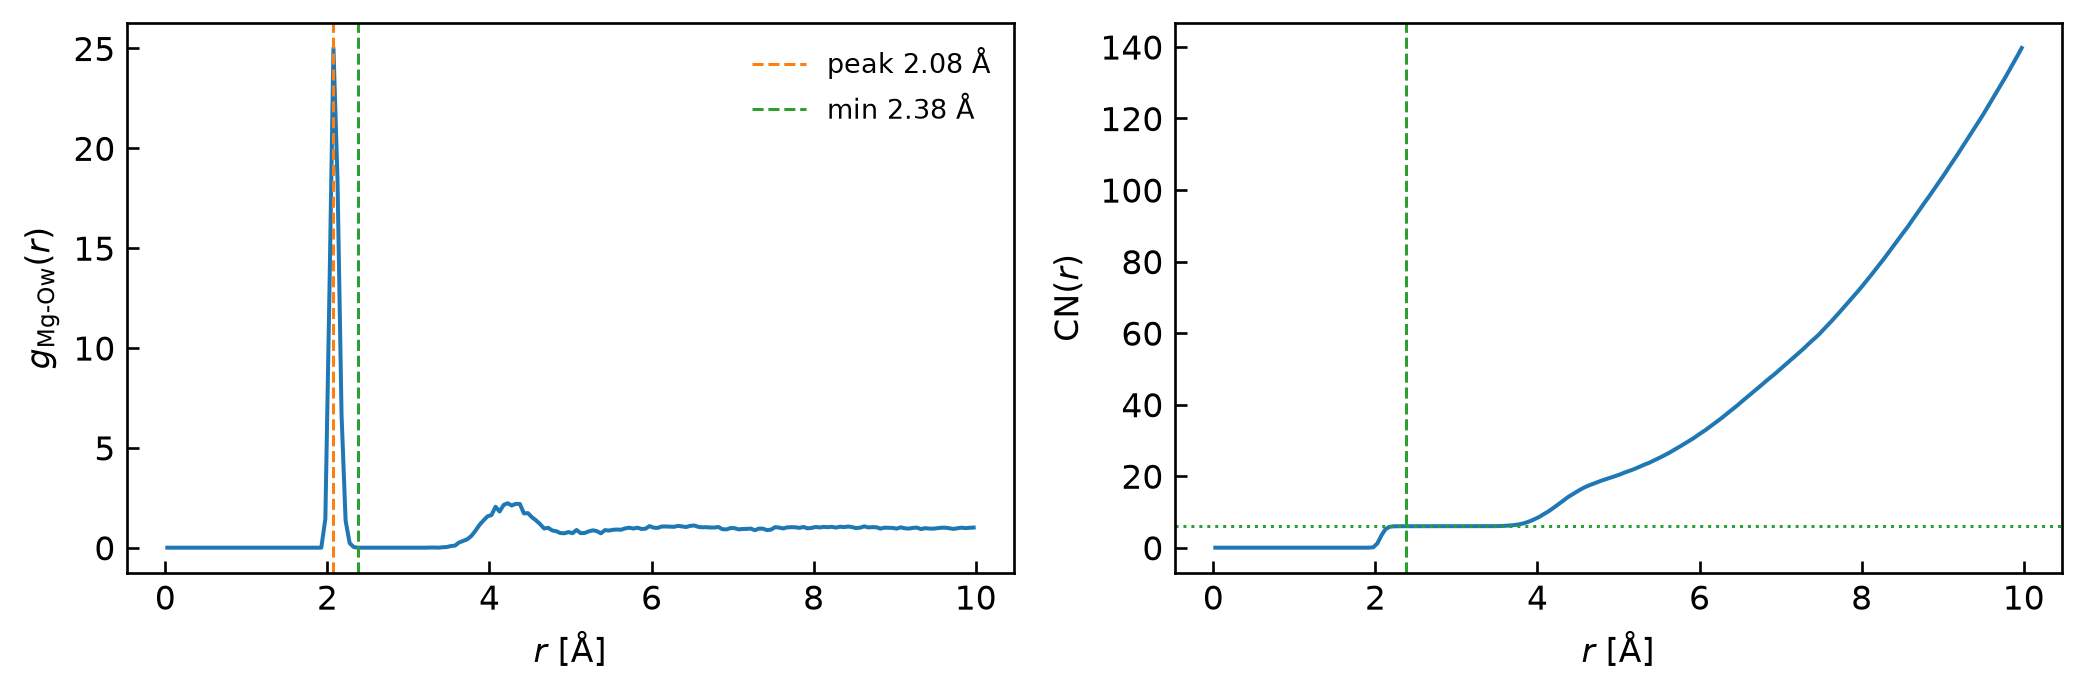

Cl_Ow: ions = 4
  IOD (1st peak) ≈ 3.175 Å  (g=4.09)
  1st minimum     ≈ 3.975 Å
  CN(r_min)       ≈ 7.59


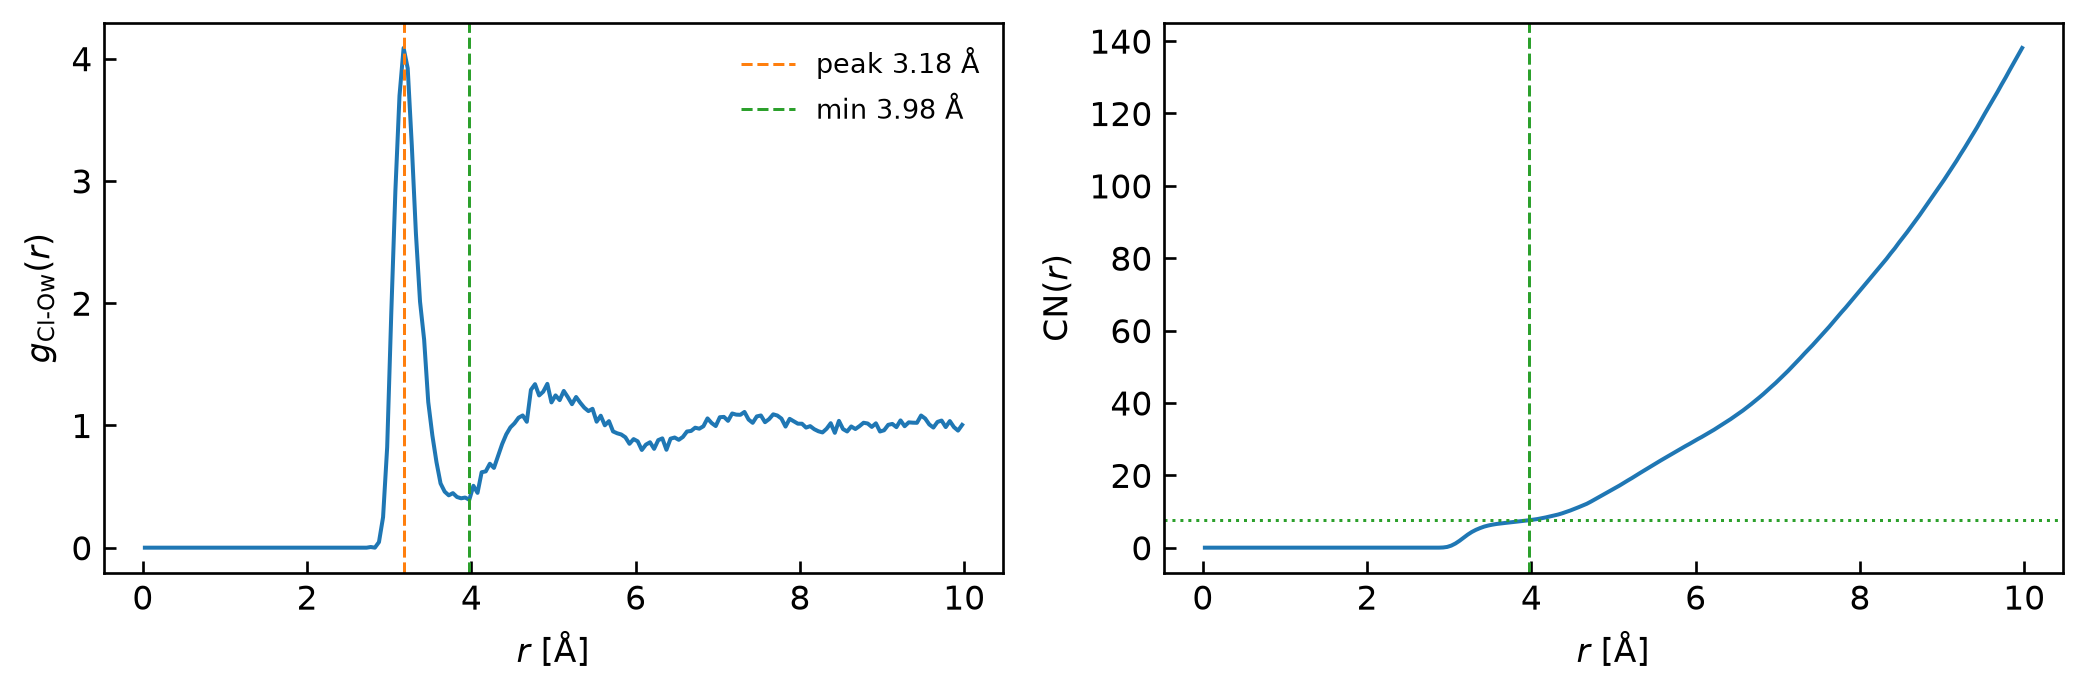

In [7]:
u = load_lammps_universe(TOPO, TRAJ, dt_fs=DT_FS, resnames=RESNAMES)
ow = u.select_atoms("type 4")
print(f"Ow = {len(ow)}, frames = {u.trajectory.n_frames}")

vols = []
for ts in u.trajectory[0:None:RDF_STEP]:
    vols.append(float(ts.volume))
rho_ow = len(ow) / float(np.mean(vols))

rdf_results = {}
for pair in RDF_PAIRS:
    key = pair["key"]
    ions = u.select_atoms(pair["ion_sel"])
    print(f"{key}: ions = {len(ions)}")
    if len(ions) == 0:
        print(f"  skip {key}: empty selection {pair['ion_sel']!r}")
        continue

    rdf = InterRDF(ions, ow, nbins=RDF_NBINS, range=RDF_RANGE, exclusion_block=None)
    rdf.run(start=0, stop=None, step=RDF_STEP)

    r = np.asarray(rdf.results.bins, dtype=float)
    g = np.asarray(rdf.results.rdf, dtype=float)
    dr = float(r[1] - r[0]) if len(r) > 1 else 0.0
    cn_cum = np.cumsum(4.0 * np.pi * rho_ow * r**2 * g * dr)

    peak_mask = (r >= pair["peak_lo"]) & (r <= pair["peak_hi"])
    if not np.any(peak_mask):
        raise RuntimeError(f"{key}: empty peak window {pair['peak_lo']}–{pair['peak_hi']} Å")
    i_peak = int(np.argmax(g[peak_mask]) + np.where(peak_mask)[0][0])
    r_peak = float(r[i_peak])
    g_peak = float(g[i_peak])

    after = (r > r_peak) & (r <= pair["min_hi"])
    if not np.any(after):
        raise RuntimeError(f"{key}: empty min window after peak")
    i_min = int(np.argmin(g[after]) + np.where(after)[0][0])
    r_min = float(r[i_min])
    cn_shell = float(cn_cum[i_min])

    print(f"  IOD (1st peak) ≈ {r_peak:.3f} Å  (g={g_peak:.2f})")
    print(f"  1st minimum     ≈ {r_min:.3f} Å")
    print(f"  CN(r_min)       ≈ {cn_shell:.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.0))
    axes[0].plot(r, g, "-")
    axes[0].axvline(r_peak, color="C1", ls="--", lw=0.9, label=f"peak {r_peak:.2f} Å")
    axes[0].axvline(r_min, color="C2", ls="--", lw=0.9, label=f"min {r_min:.2f} Å")
    axes[0].set_xlabel(r"$r$ [Å]")
    axes[0].set_ylabel(pair["ylabel"])
    axes[0].legend(fontsize=8, frameon=False)
    axes[0].tick_params(direction="in")

    axes[1].plot(r, cn_cum, "-")
    axes[1].axvline(r_min, color="C2", ls="--", lw=0.9)
    axes[1].axhline(cn_shell, color="C2", ls=":", lw=0.9)
    axes[1].set_xlabel(r"$r$ [Å]")
    axes[1].set_ylabel(r"CN$(r)$")
    axes[1].tick_params(direction="in")

    fig.tight_layout()
    fig.savefig(f"result_rdf_cn_{key}.png", bbox_inches="tight")
    plt.show()

    np.savetxt(
        f"result_rdf_{key}.dat",
        np.column_stack([r, g, cn_cum]),
        header=f"r_A  g_{key}  CN_cum",
    )
    rdf_results[key] = {
        "r_peak": r_peak,
        "r_min": r_min,
        "cn_shell": cn_shell,
        "g_peak": g_peak,
    }

# 兼容旧变量名（汇总表 / 后续单元）
r_peak = rdf_results.get("Mg_Ow", {}).get("r_peak")
r_min = rdf_results.get("Mg_Ow", {}).get("r_min")
cn_shell = rdf_results.get("Mg_Ow", {}).get("cn_shell")
r_peak_cl = rdf_results.get("Cl_Ow", {}).get("r_peak")
r_min_cl = rdf_results.get("Cl_Ow", {}).get("r_min")
cn_shell_cl = rdf_results.get("Cl_Ow", {}).get("cn_shell")


## 4. 导出水合壳 XYZ（离子 + 邻近水）

调用 `_extract_hydrated_ions.py`：对选定离子，把 Ow 落在截断半径内的**整分子水**写出到 `hydrated_ion/`。  
截断宜取上一节该离子–Ow 的**第一谷**（本例 Mg ≈ 3.2 Å，Cl ≈ 4.0 Å）。坐标相对离子做 MIC，簇内连续。脚本按 selection / cutoff 通用，不绑死 MgCl₂。

也可命令行：

```bash
# Mg（type 1）
python _extract_hydrated_ions.py --ion-sel "type 1" --ion-label Mg --cutoff 3.2 --step 50
# Cl（type 2）
python _extract_hydrated_ions.py --ion-sel "type 2" --ion-label Cl --cutoff 4.0 --step 50 \
  --out-dir hydrated_ion
# 可选残基名（仅美化 Universe，非必须）
#   --resname Mg:2 --resname Cl:4 --resname H2O:800
```


In [ ]:
from _extract_hydrated_ions import extract_hydrated_ions

HYDRATION_STEP = 100     # 每 50 帧写一次（约 100 ps）
HYDRATION_DIR = "hydrated_ion"

# 优先用 RDF 第一谷；未跑第 3 节时用经验默认
HYDRATION_JOBS = [
    {
        "ion_sel": "type 1",
        "ion_label": "Mg",
        "cutoff": float(r_min) if r_min is not None else 3.2,
    },
    {
        "ion_sel": "type 2",
        "ion_label": "Cl",
        "cutoff": float(r_min_cl) if r_min_cl is not None else 4.0,
    },
]

for job in HYDRATION_JOBS:
    out_dir = extract_hydrated_ions(
        TOPO,
        TRAJ,
        out_dir=HYDRATION_DIR,
        ion_sel=job["ion_sel"],
        water_o_sel="type 4",
        cutoff=job["cutoff"],
        start=0,
        stop=None,
        step=HYDRATION_STEP,
        dt_fs=DT_FS,
        resnames=RESNAMES,
        ion_label=job["ion_label"],
    )
    sample = sorted(Path(out_dir).glob(f"{job['ion_label']}*.xyz"))[:3]
    print(f"{job['ion_label']}: cutoff={job['cutoff']:.3f} Å  sample={sample}")


box dimensions: [28.930716 28.930716 28.930716 90.       90.       90.      ]
frame num: 287
wrote 12 XYZ → /Users/yaweiliu/MolSimulX/MolSimulX-article/downloads/C07-离子水合结构与lj1264力场/hydrated_ion  (ions=2, label=Mg, cutoff=2.375 Å, frames=0:287:50)
Mg: cutoff=2.375 Å  sample=[PosixPath('hydrated_ion/Mg01_f0000.xyz'), PosixPath('hydrated_ion/Mg01_f0050.xyz'), PosixPath('hydrated_ion/Mg01_f0100.xyz')]
box dimensions: [28.930716 28.930716 28.930716 90.       90.       90.      ]
frame num: 287
wrote 24 XYZ → /Users/yaweiliu/MolSimulX/MolSimulX-article/downloads/C07-离子水合结构与lj1264力场/hydrated_ion  (ions=4, label=Cl, cutoff=3.975 Å, frames=0:287:50)
Cl: cutoff=3.975 Å  sample=[PosixPath('hydrated_ion/Cl01_f0000.xyz'), PosixPath('hydrated_ion/Cl01_f0050.xyz'), PosixPath('hydrated_ion/Cl01_f0100.xyz')]


## 5. 结果汇总


In [9]:
rows = [
    {"quantity": "T_prod", "value": prod["temp"].mean(), "unit": "K"},
    {"quantity": "P_prod", "value": prod["press"].mean(), "unit": "atm"},
    {"quantity": "density_prod", "value": prod["density"].mean(), "unit": "g/cm^3"},
]
if r_peak is not None:
    rows.extend(
        [
            {"quantity": "IOD_MgOw", "value": r_peak, "unit": "Å"},
            {"quantity": "r_min_MgOw", "value": r_min, "unit": "Å"},
            {"quantity": "CN_MgOw", "value": cn_shell, "unit": "-"},
        ]
    )
if r_peak_cl is not None:
    rows.extend(
        [
            {"quantity": "IOD_ClOw", "value": r_peak_cl, "unit": "Å"},
            {"quantity": "r_min_ClOw", "value": r_min_cl, "unit": "Å"},
            {"quantity": "CN_ClOw", "value": cn_shell_cl, "unit": "-"},
        ]
    )
for job in HYDRATION_JOBS:
    rows.append(
        {
            "quantity": f"hydration_cutoff_{job['ion_label']}",
            "value": job["cutoff"],
            "unit": "Å",
        }
    )

summary = pd.DataFrame(rows)
summary.to_csv("result_summary.csv", index=False)
summary


,quantity,value,unit
0,T_prod,297.689024,K
1,P_prod,11.763182,atm
2,density_prod,0.960448,g/cm^3
3,IOD_MgOw,2.075000,Å
4,r_min_MgOw,2.375000,Å
5,CN_MgOw,5.999714,-
6,IOD_ClOw,3.175000,Å
7,r_min_ClOw,3.975000,Å
8,CN_ClOw,7.588705,-
9,hydration_cutoff_Mg,2.375000,Å
